# Notebook 04 - TF-IDF Baseline Models

## Imports and Setup

This section loads all required libraries, project configuration, and global settings for the notebook.

### Data and Visualisation
- `pandas`, `numpy` for data manipulation
- `matplotlib`, `seaborn` for visualisation

### Modelling
- Model selection utilities and machine learning models from `scikit-learn`
- TF-IDF vectorisation for text features
- Calibration and evaluation metrics

### NLP Setup
- NLTK stopwords downloaded and loaded

### Project Configuration
- Paths, constants, and parameters loaded from `config.py`

### Global Settings
- Plot styling configured
- Colour palette defined
- Stopwords initialised

### Environment
- CPU-only execution
- Dataset: MIMIC-IV v3.1

In [1]:
# Add Project Root Directory
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualisation Library
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import pickle, warnings
warnings.filterwarnings('ignore')  # suppress warnings

# Model Selection Utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Text Vectorisation Library
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Calibration Utilities
from sklearn.calibration import CalibratedClassifierCV

# Evaluation Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
)

# Class Imbalance Utilities
from sklearn.utils.class_weight import compute_class_weight

# NLTK Setup
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Project Config 
from config import (
    LABELLED_DATASET, PROCESSED_DIR,
    BEST_BASELINE_PKL, BASELINE_RESULTS_CSV,
    PLOTS_DIR, TEST_SIZE, VAL_SIZE, RANDOM_STATE,
)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

# Stopwords Set
STOP = list(stopwords.words('english'))

## Data Loading and Splitting

This section loads the labelled dataset, extracts features and labels, and performs a stratified train-validation-test split.

### Dataset
- Loaded from `LABELLED_DATASET`
- Shape printed for verification

### Features and Labels
- `X`: clinical narratives (converted to string)
- `y`: 30-day readmission label (binary)

### Data Splitting
- Stratified split to preserve class distribution
- Train → remaining split into validation and test sets

### Summary Statistics
- Dataset sizes for each split
- Training label distribution
- Positive class rate

### Class Imbalance Handling
- Class weights computed using `balanced` mode
- Stored as dictionary for model training

In [2]:
# Load Labelled Dataset
dataset = pd.read_csv(LABELLED_DATASET)
print(f'Loaded: {dataset.shape}')

# Extract Features and Labels
X = dataset['narrative'].astype(str).to_numpy()
y = dataset['readmission_30d'].astype(int).to_numpy()

# Train / Validation / Test Split (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_temp)

# Dataset Summary
print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Positive rate : {y_train.mean()*100:.1f}%')

# Compute Class Weights (for Imbalance Handling)
cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {0: float(cw_arr[0]), 1: float(cw_arr[1])}

print(f'Class weights : {cw_dict}')

Loaded: (14452, 10)
Train : 11,561 | Val : 1,445 | Test : 1,446
Train label dist : [9301 2260]
Positive rate : 19.5%
Class weights : {0: 0.6214923126545533, 1: 2.557743362831858}


## TF-IDF Vectorisation

This section converts raw text data into numerical feature representations using TF-IDF.

### Vectoriser Configuration
- `max_features=15000`: limits vocabulary size
- `ngram_range=(1, 2)`: uses unigrams and bigrams
- `stop_words=STOP`: removes common English stopwords
- `sublinear_tf=True`: applies log-scaling to term frequency
- `min_df=3`: ignores rare terms appearing in fewer than 3 documents

### Transformation
- Fit on training data (`X_train`)
- Transform applied to validation and test sets

### Output
- Sparse matrices representing TF-IDF features
- Shapes printed for verification

In [3]:
# TF-IDF Vectorisation
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=STOP,
    sublinear_tf=True,
    min_df=3,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# TF-IDF Matrix Shapes
print(f"TF-IDF train matrix : {X_train_tfidf.shape}")
print(f"TF-IDF test  matrix : {X_test_tfidf.shape}")

TF-IDF train matrix : (11561, 15000)
TF-IDF test  matrix : (1446, 15000)


## Model Training and Evaluation

This section defines baseline models, trains them on TF-IDF features, and evaluates their performance on the test set.

### Models
- Logistic Regression
- Random Forest
- Linear SVM (with probability calibration)

All models use `class_weight='balanced'` to address class imbalance.

### Training
- Models are trained on `X_train_tfidf` and `y_train`

### Evaluation Metrics
- ROC-AUC (discrimination ability)
- PR-AUC (performance on imbalanced data)
- Classification report (precision, recall, F1-score)

### Outputs
- Predictions and probabilities stored for each model
- Metrics saved in `results` dictionary
- Performance printed for comparison

In [4]:
# Define Models
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            C=0.5,
        ),
        cv=3,
    ),
}

# Train and Evaluate Models
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "report": report,
    }

    print(f"  ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Readmitted", "Readmitted"],
            zero_division=0,
        )
    )

Training Logistic Regression...
  ROC-AUC: 0.6785 | PR-AUC: 0.3943
                precision    recall  f1-score   support

Not Readmitted       0.87      0.75      0.80      1163
    Readmitted       0.34      0.53      0.41       283

      accuracy                           0.71      1446
     macro avg       0.60      0.64      0.61      1446
  weighted avg       0.76      0.71      0.73      1446

Training Random Forest...
  ROC-AUC: 0.6736 | PR-AUC: 0.3921
                precision    recall  f1-score   support

Not Readmitted       0.86      0.86      0.86      1163
    Readmitted       0.41      0.40      0.41       283

      accuracy                           0.77      1446
     macro avg       0.64      0.63      0.63      1446
  weighted avg       0.77      0.77      0.77      1446

Training Linear SVM...
  ROC-AUC: 0.6685 | PR-AUC: 0.3881
                precision    recall  f1-score   support

Not Readmitted       0.81      1.00      0.89      1163
    Readmitted       0.

## Cross-Validation

This section evaluates model performance using stratified k-fold cross-validation on the training data.

### Setup
- `StratifiedKFold` with 5 splits
- Shuffling enabled for randomness
- Stratification preserves class distribution across folds

### Evaluation Metrics
- F1-weighted: accounts for class imbalance
- ROC-AUC: measures ranking performance

### Process
- Each model is evaluated using cross-validation
- Mean and standard deviation of scores are reported

### Output
- Provides more robust performance estimates compared to a single train-test split

In [5]:
# Cross-Validation Setup
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Cross-Validate Models
for name, model in models.items():
    print(f"Cross-validating {name}...")

    scores = cross_validate(
        model,
        X_train_tfidf,
        y_train,
        cv=cv,
        scoring=["f1_weighted", "roc_auc"],
        n_jobs=-1,
    )

    print(
        f'  F1-weighted : {scores["test_f1_weighted"].mean():.4f} '
        f'+/- {scores["test_f1_weighted"].std():.4f}'
    )
    print(
        f'  ROC-AUC     : {scores["test_roc_auc"].mean():.4f} '
        f'+/- {scores["test_roc_auc"].std():.4f}'
    )

Cross-validating Logistic Regression...
  F1-weighted : 0.7235 +/- 0.0097
  ROC-AUC     : 0.6959 +/- 0.0152
Cross-validating Random Forest...
  F1-weighted : 0.7563 +/- 0.0117
  ROC-AUC     : 0.6774 +/- 0.0160
Cross-validating Linear SVM...
  F1-weighted : 0.7299 +/- 0.0043
  ROC-AUC     : 0.6836 +/- 0.0151


## ROC and Precision-Recall Curves

This section visualises model performance using ROC and Precision-Recall curves.

### ROC Curve
- Plots True Positive Rate vs False Positive Rate
- Includes diagonal baseline (random classifier)
- AUC displayed for each model

### Precision-Recall Curve
- Plots Precision vs Recall
- More informative for imbalanced datasets
- Baseline corresponds to positive class prevalence

### Visualisation
- Separate subplots for ROC and PR curves
- Consistent colour mapping across models
- Legends include performance metrics

### Output
- Figure saved to `PLOTS_DIR`
- Displays comparative performance of baseline models

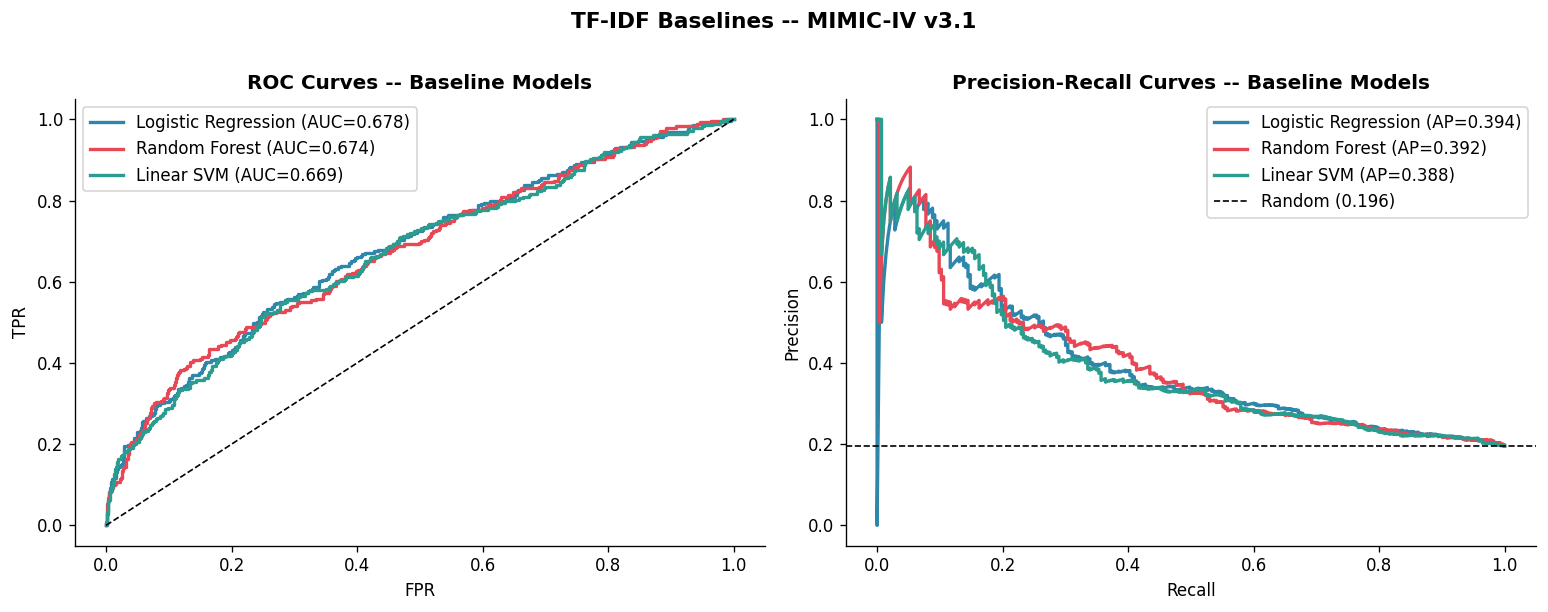

In [6]:
# Colour Mapping for Models
colors = {
    "Logistic Regression": "#2E86AB",
    "Random Forest": "#E84855",
    "Linear SVM": "#2A9D8F",
}

# ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(
        fpr,
        tpr,
        label=f'{name} (AUC={res["roc_auc"]:.3f})',
        color=colors[name],
        lw=2,
    )

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curves -- Baseline Models", fontweight="bold")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()

# Precision-Recall Curves
baseline_pr = y_test.mean()

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    axes[1].plot(
        rec,
        prec,
        label=f'{name} (AP={res["pr_auc"]:.3f})',
        color=colors[name],
        lw=2,
    )

axes[1].axhline(
    y=baseline_pr,
    color="k",
    linestyle="--",
    lw=1,
    label=f"Random ({baseline_pr:.3f})",
)

axes[1].set_title(
    "Precision-Recall Curves -- Baseline Models",
    fontweight="bold",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Save and Display Figure
plt.suptitle(
    "TF-IDF Baselines -- MIMIC-IV v3.1",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(
    f"{PLOTS_DIR}/base_01_roc_pr_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Confusion Matrices

This section visualises classification performance using confusion matrices for each model.

### Purpose
- Shows distribution of true vs predicted labels
- Helps identify types of errors (false positives, false negatives)

### Visualisation
- One subplot per model
- Consistent label ordering:
  - Not Readmitted
  - Readmitted
- Blue colour map for intensity

### Output
- Figure saved to `PLOTS_DIR`
- Enables comparison of model prediction behaviour

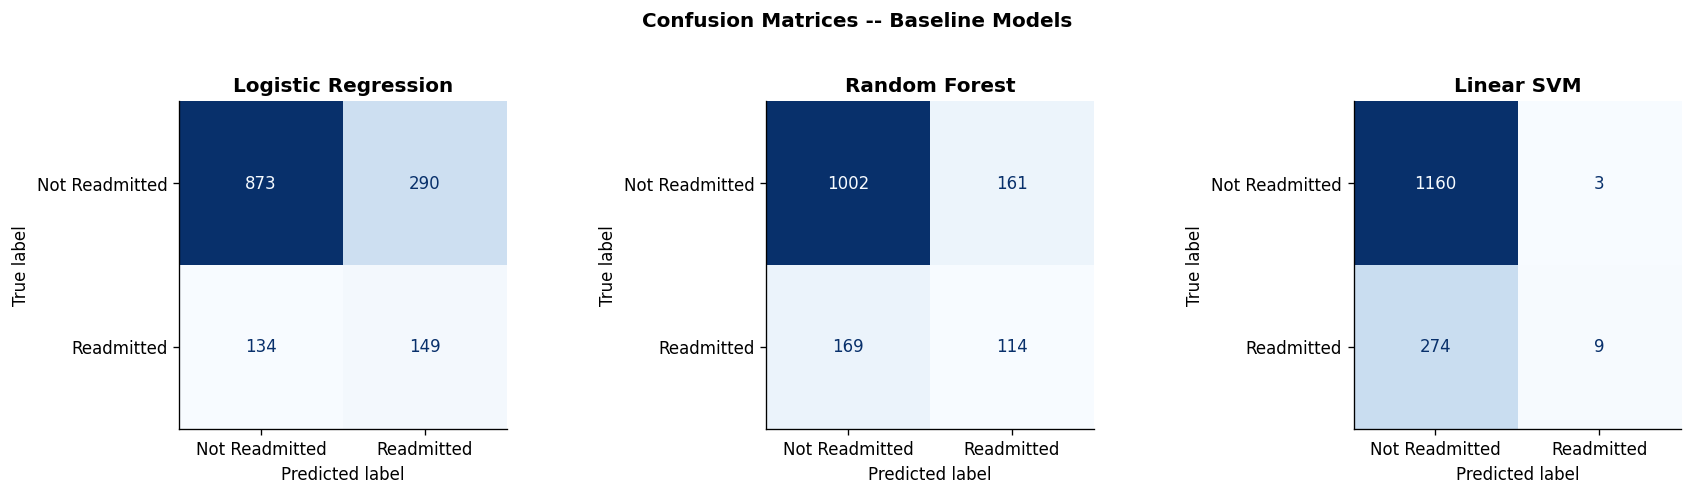

In [7]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Not Readmitted", "Readmitted"],
    ).plot(
        ax=ax,
        colorbar=False,
        cmap="Blues",
    )

    ax.set_title(name, fontweight="bold")

# Save and Display Figure
plt.suptitle(
    "Confusion Matrices -- Baseline Models",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    f"{PLOTS_DIR}/base_02_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Logistic Regression Feature Importance

This section analyses feature importance using coefficients from the Logistic Regression model.

### Method
- Coefficients from the trained model are extracted
- Features are ranked based on coefficient magnitude

### Interpretation
- Positive coefficients → associated with higher readmission risk
- Negative coefficients → associated with lower readmission risk

### Visualisation
- Top 15 positive features (readmission predictors)
- Top 15 negative features (non-readmission predictors)
- Horizontal bar plots for readability

### Output
- Figure saved to `PLOTS_DIR`
- Provides interpretability of model behaviour

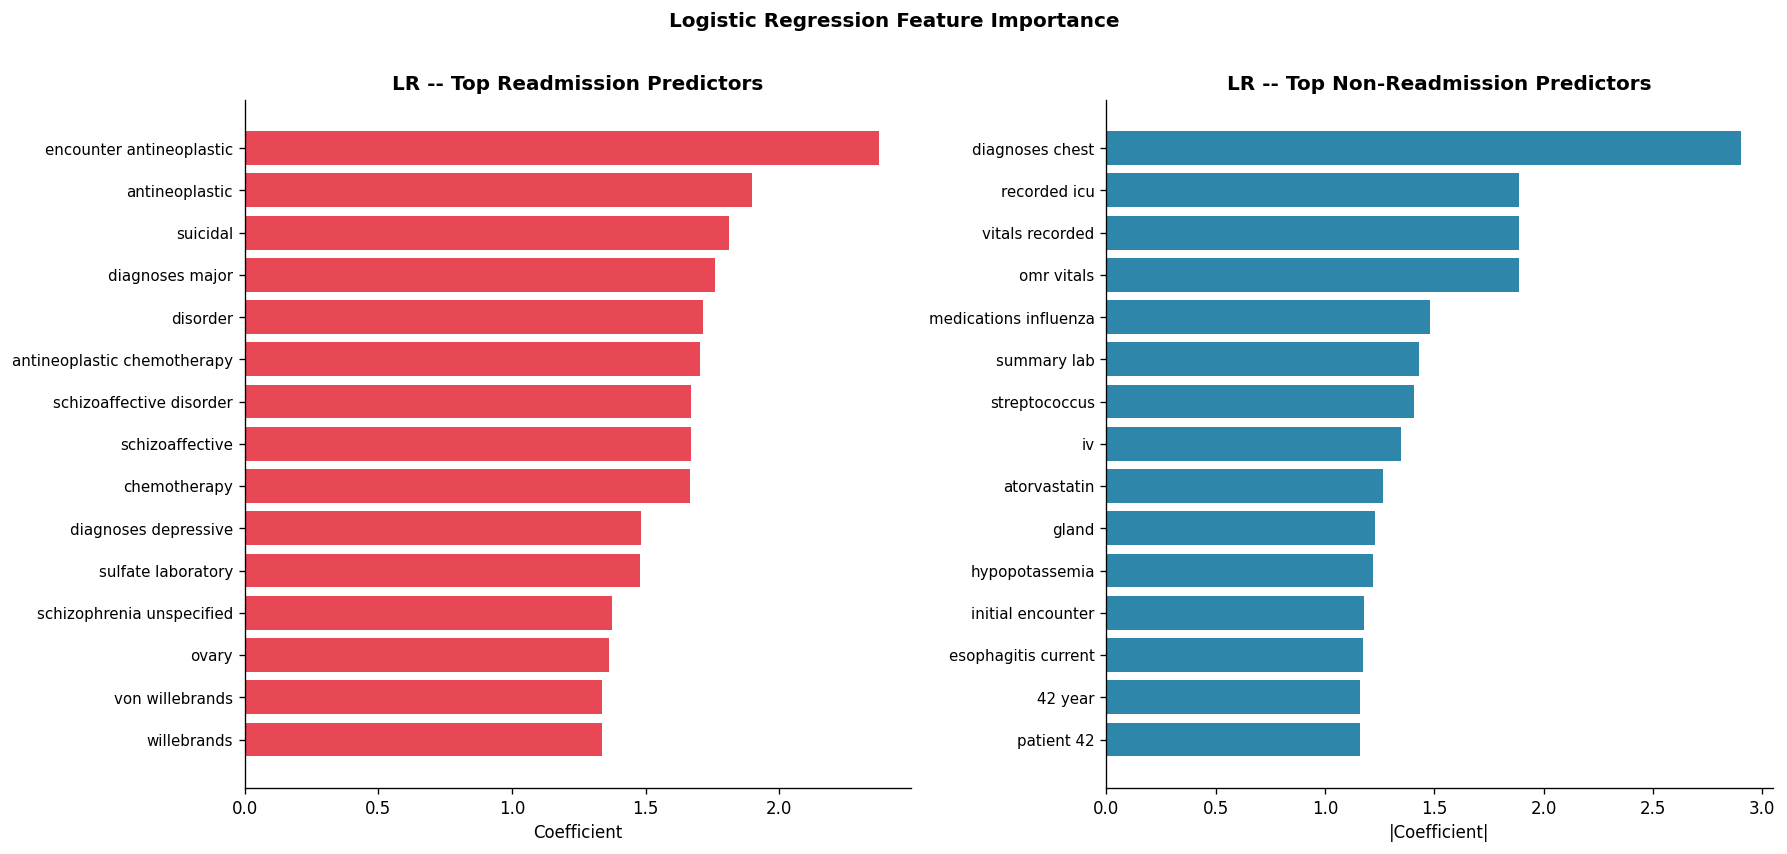

In [8]:
# Logistic Regression Feature Importance
lr_model = results["Logistic Regression"]["model"]

coef = lr_model.coef_[0]
feat_names = np.array(tfidf.get_feature_names_out())

top_pos_idx = coef.argsort()[-20:][::-1]
top_neg_idx = coef.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top Positive Coefficients (Readmission Predictors)
axes[0].barh(
    range(15),
    coef[top_pos_idx[:15]][::-1],
    color=PALETTE[1],
)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(
    feat_names[top_pos_idx[:15]][::-1],
    fontsize=9,
)
axes[0].set_title(
    "LR -- Top Readmission Predictors",
    fontweight="bold",
)
axes[0].set_xlabel("Coefficient")

# Top Negative Coefficients (Non-Readmission Predictors)
axes[1].barh(
    range(15),
    abs(coef[top_neg_idx[:15]][::-1]),
    color=PALETTE[0],
)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(
    feat_names[top_neg_idx[:15]][::-1],
    fontsize=9,
)
axes[1].set_title(
    "LR -- Top Non-Readmission Predictors",
    fontweight="bold",
)
axes[1].set_xlabel("|Coefficient|")

# Save and Display Figure
plt.suptitle(
    "Logistic Regression Feature Importance",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(
    f"{PLOTS_DIR}/base_03_lr_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Results Summary and Model Saving

This section compiles evaluation metrics, saves results, and stores the best-performing model.

### Summary Table
- Metrics extracted from classification reports and evaluation results:
  - Accuracy
  - Precision, Recall, F1-score (positive class)
  - Weighted F1-score
  - ROC-AUC and PR-AUC

### Output
- Results stored in a DataFrame
- Saved to `BASELINE_RESULTS_CSV`

### Best Model Selection
- Model selected based on highest ROC-AUC score

### Model Persistence
- Best model, TF-IDF vectoriser, and predictions saved using `pickle`
- Output saved to `BEST_BASELINE_PKL`

### Purpose
- Enables reproducibility and reuse of the best baseline model

In [9]:
# Compile Evaluation Summary
summary_rows = []

for name, res in results.items():
    r = res["report"]

    summary_rows.append(
        {
            "Model": name,
            "Type": "Baseline",
            "Accuracy": r["accuracy"],
            "Precision_Pos": r["1"]["precision"],
            "Recall_Pos": r["1"]["recall"],
            "F1_Pos": r["1"]["f1-score"],
            "F1_Weighted": r["weighted avg"]["f1-score"],
            "ROC_AUC": res["roc_auc"],
            "PR_AUC": res["pr_auc"],
        }
    )

# Create Summary DataFrame
summary_df = pd.DataFrame(summary_rows)

# Save Results
summary_df.to_csv(BASELINE_RESULTS_CSV, index=False)
print("Baseline results saved.")
print(summary_df.to_string(index=False, float_format="{:.4f}".format))

# Select Best Model (by ROC-AUC)
best_name = summary_df.loc[summary_df["ROC_AUC"].idxmax(), "Model"]
best_res = results[best_name]

print(f"\nBest baseline: {best_name}")

# Save Best Model
with open(BEST_BASELINE_PKL, "wb") as f:
    pickle.dump(
        {
            "name": best_name,
            "model": best_res["model"],
            "tfidf": tfidf,
            "y_test": y_test,
            "y_pred": best_res["y_pred"],
            "y_prob": best_res["y_prob"],
        },
        f,
    )

print(f"Best baseline model saved -> {BEST_BASELINE_PKL}")

Baseline results saved.
              Model     Type  Accuracy  Precision_Pos  Recall_Pos  F1_Pos  F1_Weighted  ROC_AUC  PR_AUC
Logistic Regression Baseline    0.7068         0.3394      0.5265  0.4127       0.7279   0.6785  0.3943
      Random Forest Baseline    0.7718         0.4145      0.4028  0.4086       0.7705   0.6736  0.3921
         Linear SVM Baseline    0.8084         0.7500      0.0318  0.0610       0.7304   0.6685  0.3881

Best baseline: Logistic Regression
Best baseline model saved -> D:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\medical_nlp_deterioration\data\processed\best_baseline.pkl
